In [1]:
# Ensure working directory to project code folder
import os

# Edit this path to point at your local `code/` folder (the directory containing `GridMaze/`).
os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# plotting settings
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec
from importlib import reload

In [3]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import summary

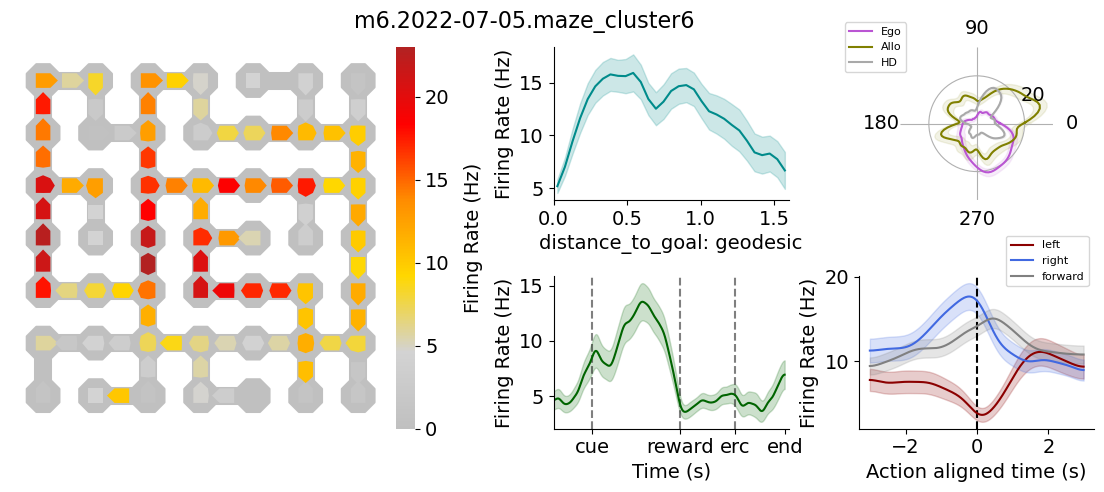

In [ ]:
reload(summary)
Cluster = gc.get_cluster("m6.2022-07-05.maze_cluster6")
fig = summary.plot_tuning_summary_concise(Cluster)
# fig.savefig("../results/nbeGLM/figures/cluster_tuning_summary.pdf")

In [3]:
from GridMaze.analysis.neGLM import load_model_sets as lms
from GridMaze.analysis.neGLM import model_comparisons as mc

reload(lms)
reload(mc)

<module 'GridMaze.analysis.neGLM.model_comparisons' from '/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/neGLM/model_comparisons.py'>

# model performance validation

baseline vs embedding:
                      feature_group model_type     t_stat     p_val  \
0                   place_direction  baseline2   7.985724  0.000497   
1                   place_direction   baseline  11.806885  0.000077   
2  place_direction_distance_to_goal  baseline2   8.241120  0.000429   
3  place_direction_distance_to_goal   baseline  11.308994  0.000095   
4                             place   baseline   6.054119  0.001773   

   p_val_corr  
0    0.000621  
1    0.000236  
2    0.000621  
3    0.000236  
4    0.001773  


(-0.01, 0.15)

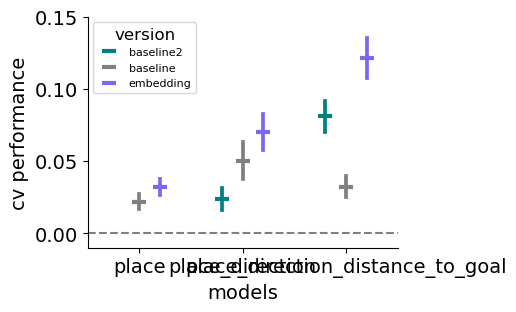

In [6]:
nbe_validation = lms.load_model_set_cv_scores(
    model_set="performance_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
f, ax = plt.subplots(figsize=(4, 3))
mc.plot_performance_validation(nbe_validation, ax=ax, outlier_threshold=-0.6)
ax.set_ylim(-0.01, 0.15)
# f.savefig("../results/neGLM/figures/performance_validation.pdf")

# feature-group interactions validation

In [7]:
interaction_validation_results = lms.load_model_set_cv_scores(
    "interaction_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)

place_direction_factorised vs place_direction_nonlinear
t_stat: -5.306830646355353, p_val: 0.003174222287973421
place_direction_distance_to_goal_factorised vs place_direction_distance_to_goal_nonlinear
t_stat: 1.4179475992257404, p_val: 0.2154064267641584


(-0.03, 0.15)

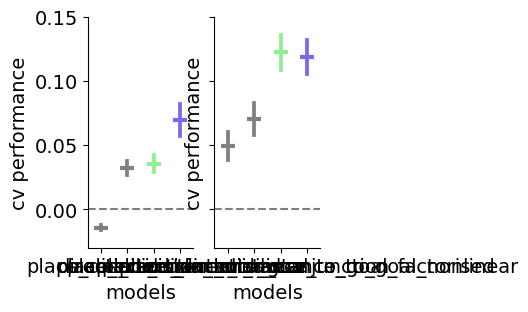

In [8]:
reload(mc)
f, axes = plt.subplots(1, 2, figsize=(3, 3), sharey=True)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=["place", "direction", "place_direction_factorised", "place_direction_nonlinear"],
    ax=axes[0],
)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=[
        "place_direction_conjunction",
        "distance_to_goal",
        "place_direction_distance_to_goal_factorised",
        "place_direction_distance_to_goal_nonlinear",
    ],
    ax=axes[1],
)
axes[0].set_ylim(-0.03, 0.15)
# f.savefig("../results/nbeGLM/figures/interaction_validation.pdf")

# unique variance explained

In [9]:
from GridMaze.analysis.neGLM import variance_explained as ve

reload(ve)

<module 'GridMaze.analysis.neGLM.variance_explained' from '/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/neGLM/variance_explained.py'>

In [69]:
late_sessions = False
if late_sessions:
    variance_explained_results = lms.load_model_set_cv_scores(
        "variance_explained", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
    )
else:
    variance_explained_results = lms.load_model_set_cv_scores(
        "variance_explained_all_sessions", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
    )

reduced_models = [
    "remove_distance_to_goal",
    "remove_place_direction",
]
cpd_df = ve.get_cpd_df(variance_explained_results, reduced_models=reduced_models, outlier_threshold=-0.6)
feature_tuned_df = ve.get_feature_tuned_df(variance_explained_results, reduced_models=reduced_models, alpha=0.01)

            feature    t_stat     p_val  p_val_corr
0  distance_to_goal  4.854024  0.002329    0.002329
1   place_direction  6.618263  0.000593    0.001185


(-0.5, 10.0)

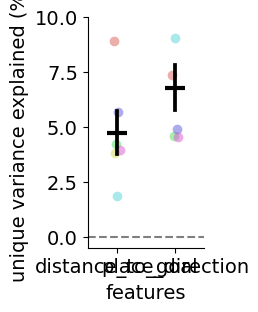

In [70]:
models = [f.split("_", 1)[-1] for f in reduced_models]
reload(ve)
f, ax = plt.subplots(figsize=(1.5, 3))
ve.plot_variance_explained(
    cpd_df, features=models, plot_single_subject=True, print_stats=True, orientation="vertical", ax=ax
)
ax.set_ylim(-0.5, 10)
# f.savefig("../results/nbeGLM/figures/unique_variance_explained.pdf")

(-0.1, 1.0)

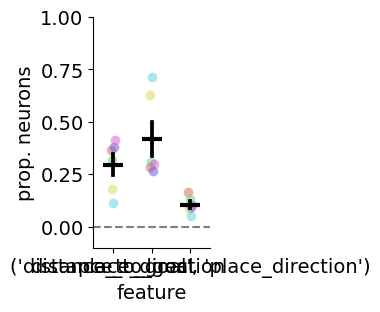

In [71]:
reload(ve)
f, ax = plt.subplots(figsize=(1.5, 3))
ve.plot_summary_pointplot(
    feature_tuned_df,
    models=models,
    ax=ax,
)
ax.set_ylim(-0.1, 1)
# f.savefig("../results/nbeGLM/figures/feature_tuning_summary.pdf")

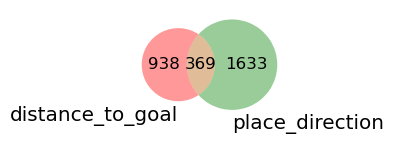

In [72]:
reload(ve)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ve.plot_summary_venn_diagram(
    feature_tuned_df,
    models=models,
    ax=ax,
)
# fig.savefig("../results/nbeGLM/figures/feature_tuning_venn.pdf")

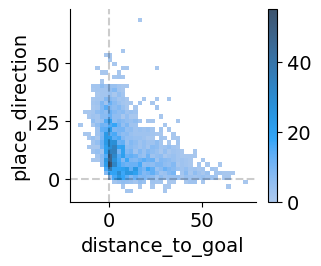

In [74]:
reload(ve)
f, ax = plt.subplots(1, 1, figsize=(3, 2.5))
ve.plot_cpd_clusters(cpd_df, feature_tuned_df, remove_no_unique_variance_clusters=True, ax=ax)
# f.savefig("../results/nbeGLM/figures/cpd_scatter.pdf")

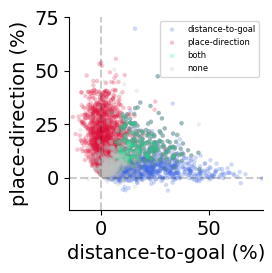

In [75]:
reload(ve)
f, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
ve.plot_cpd_scatter(cpd_df, feature_tuned_df, remove_no_unique_variance_clusters=False, ax=ax)

## what other features explain variance in the data?

In [4]:
# need to rerun results
results_df = lms.load_model_set_cv_scores(
    "other_features", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)

                                             model_1  \
0                                    place_direction   
1                   place_direction.distance_to_goal   
2              place_direction.distance_to_goal.goal   
3  place_direction.distance_to_goal.goal.egocentr...   

                                             model_2     t_stat     p_val  \
0                   place_direction.distance_to_goal   4.293056  0.003883   
1              place_direction.distance_to_goal.goal  -1.910475  0.942842   
2  place_direction.distance_to_goal.goal.egocentr...   7.388154  0.000357   
3  place_direction.distance_to_goal.goal.egocentr...  15.483675  0.000010   

   p_val_corr  
0    0.005178  
1    0.942842  
2    0.000714  
3    0.000041  


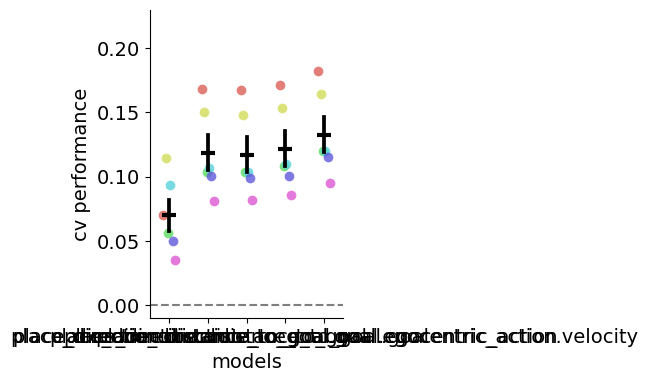

In [5]:
reload(mc)
f, ax = plt.subplots(figsize=(2.5, 4))
mc.plot_other_feature_results(
    results_df,
    models=[
        "place_direction",
        "place_direction.distance_to_goal",
        "place_direction.distance_to_goal.goal",
        "place_direction.distance_to_goal.goal.egocentric_action",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity",
    ],
    outlier_threshold=-0.6,
    plot_single_subjects=True,
    print_stats=True,
    stats_comparisons=[
        ("place_direction", "place_direction.distance_to_goal"),
        ("place_direction.distance_to_goal", "place_direction.distance_to_goal.goal"),
        ("place_direction.distance_to_goal.goal", "place_direction.distance_to_goal.goal.egocentric_action"),
        (
            "place_direction.distance_to_goal.goal.egocentric_action",
            "place_direction.distance_to_goal.goal.egocentric_action.velocity",
        ),
    ],
    ax=ax,
)
ax.set_ylim(-0.01, 0.23)
f.savefig("../results/neGLM/figures/other_features_test.pdf")

In [6]:
results_df.model_name.unique()

array(['place_direction.distance_to_goal.goal.egocentric_action.velocity',
       'place_direction.distance_to_goal.goal',
       'place_direction.distance_to_goal.goal.egocentric_action.speed',
       'place_direction.distance_to_goal',
       'place_direction.distance_to_goal.head_direction',
       'place_direction.distance_to_goal.goal.egocentric_action',
       'place_direction.distance_to_goal.allocentric_angle_to_goal',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.allocentric_angle_to_goal.egocentric_angle_to_goal',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.allocentric_angle_to_goal.egocentric_angle_to_goal',
       'place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.allocentric_angle_to_goal',
       'place_direction.distance_to_goal.egocentric_angle_to_goal.head_direction',
       'place

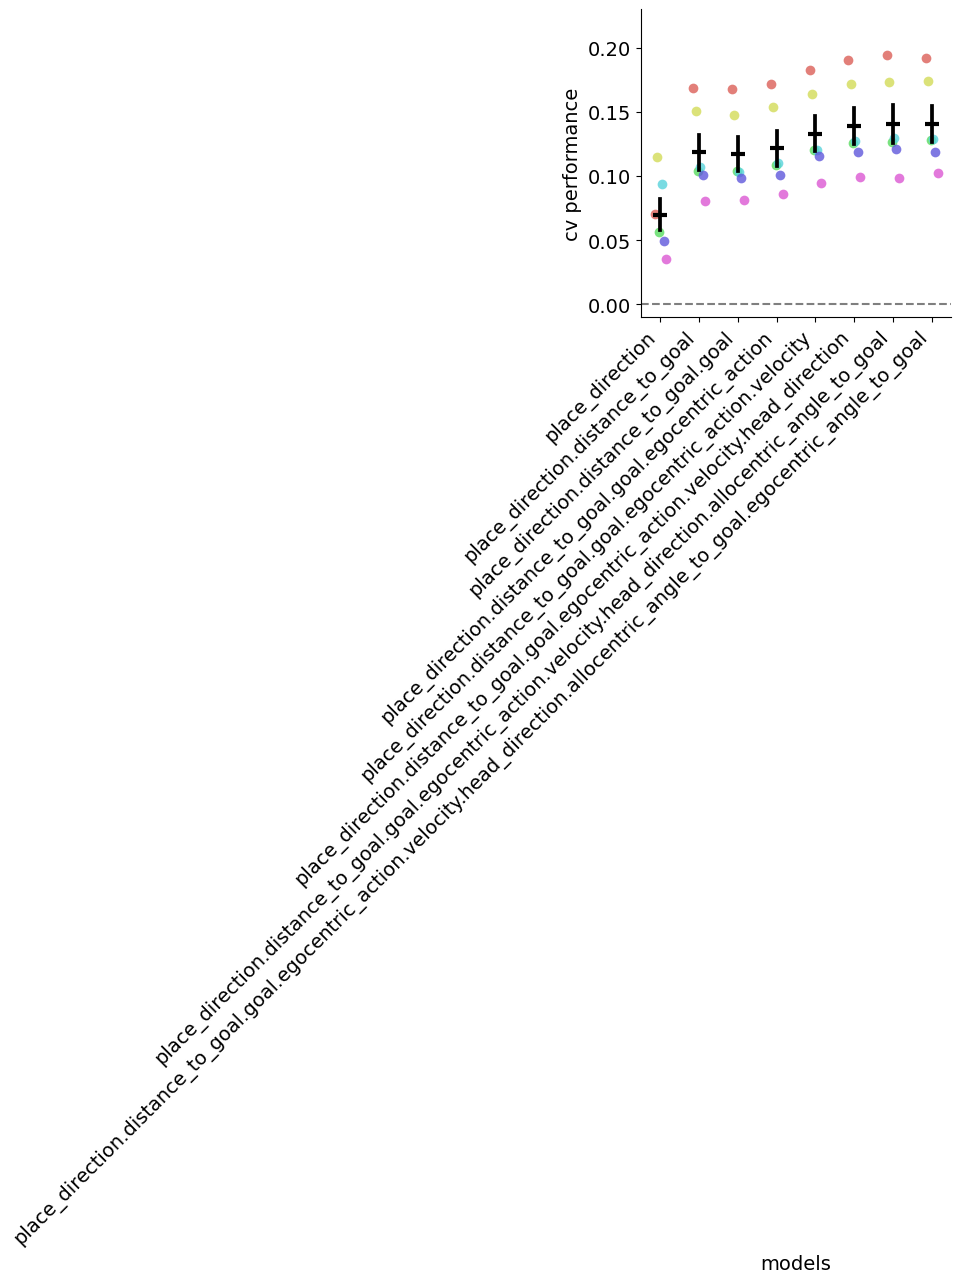

In [ ]:
# control: different goal reps
reload(mc)
f, ax = plt.subplots(figsize=(4, 4))
stats_df = mc.plot_model_comparison(
    results_df,
    models=[
        "place_direction",
        "place_direction.distance_to_goal",
        "place_direction.distance_to_goal.goal",
        "place_direction.distance_to_goal.goal.egocentric_action",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.allocentric_angle_to_goal",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.allocentric_angle_to_goal.egocentric_angle_to_goal",
    ],
    outlier_threshold=-0.6,
    plot_single_subjects=True,
    stats_comparisons=[
        (
            "place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction",
            "place_direction.distance_to_goal.goal.egocentric_action.velocity.head_direction.allocentric_angle_to_goal",
        ),
    ],
    ax=ax,
)
ax.set_ylim(-0.01, 0.23)
# f.savefig("../results/neGLM/figures/other_features_control_1.pdf")
stats_df

                                             model_1  \
0  place_direction.distance_to_goal.goal.egocentr...   
1  place_direction.distance_to_goal.goal.egocentr...   
2  place_direction.distance_to_goal.goal.egocentr...   

                                             model_2     t_stat     p_val  \
0  place_direction.distance_to_goal.goal.egocentr...   2.433401  0.029566   
1  place_direction.distance_to_goal.goal.egocentr...  15.580971  0.000010   
2  place_direction.distance_to_goal.goal.egocentr...   2.795680  0.019094   

   p_val_corr  
0    0.029566  
1    0.000030  
2    0.028641  


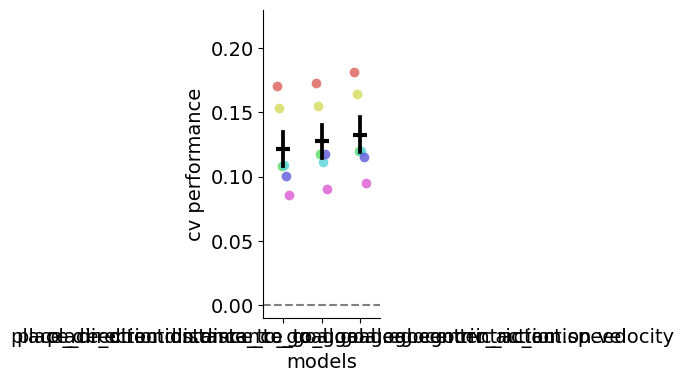

In [62]:
reload(mc)
f, ax = plt.subplots(figsize=(1.5, 4))
mc.plot_other_feature_results(
    results_df,
    models=[
        "place_direction.distance_to_goal.goal.egocentric_action",
        "place_direction.distance_to_goal.goal.egocentric_action.speed",
        "place_direction.distance_to_goal.goal.egocentric_action.velocity",
    ],
    outlier_threshold=-0.6,
    plot_single_subjects=True,
    print_stats=True,
    stats_comparisons=[
        (
            "place_direction.distance_to_goal.goal.egocentric_action",
            "place_direction.distance_to_goal.goal.egocentric_action.speed",
        ),
        (
            "place_direction.distance_to_goal.goal.egocentric_action",
            "place_direction.distance_to_goal.goal.egocentric_action.velocity",
        ),
        (
            "place_direction.distance_to_goal.goal.egocentric_action.speed",
            "place_direction.distance_to_goal.goal.egocentric_action.velocity",
        ),
    ],
    ax=ax,
)
ax.set_ylim(-0.01, 0.23)
f.savefig("../results/neGLM/figures/other_features_control_2.pdf")

,model_1,model_2,t_stat,p_val,p_val_corr
0,place_direction.distance_to_goal.head_direction,place_direction-distance_to_goal-head_direction,-5.168069,0.003561,0.010682
1,place_direction.distance_to_goal.head_direction,place_direction.distance_to_goal.egocentric_an...,-3.590766,0.015695,0.023543
2,place_direction.distance_to_goal.egocentric_an...,place_direction-distance_to_goal-egocentric_an...,0.733288,0.496301,0.496301


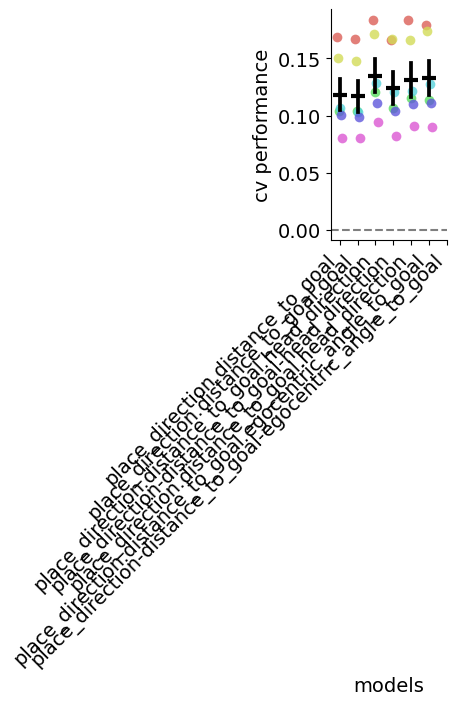

In [ ]:
# angle to goal controls
reload(mc)
reload(lms)
results_df = results_df = lms.load_model_set_cv_scores(
    "angle_to_goal", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
f, ax = plt.subplots(figsize=(3, 4))
mc.plot_model_comparison(
    results_df,
    ax=ax,
    models=[
        "place_direction.distance_to_goal",
        "place_direction.distance_to_goal.goal",
        "place_direction.distance_to_goal.head_direction",
        "place_direction-distance_to_goal-head_direction",
        "place_direction.distance_to_goal.head_direction",
        "place_direction.distance_to_goal.egocentric_angle_to_goal",
        "place_direction-distance_to_goal-egocentric_angle_to_goal",
    ],
    stats_comparisons=[
        (
            "place_direction.distance_to_goal.head_direction",
            "place_direction-distance_to_goal-head_direction",
        ),
        (
            "place_direction.distance_to_goal.head_direction",
            "place_direction.distance_to_goal.egocentric_angle_to_goal",
        ),
        (
            "place_direction.distance_to_goal.egocentric_angle_to_goal",
            "place_direction-distance_to_goal-egocentric_angle_to_goal",
        ),
    ],
)
f.savefig("../results/neGLM/figures/angle_to_goal_control.pdf")

## test unique variance explained of these new variables

In [80]:
late_sessions = True
if late_sessions:
    results_df = lms.load_model_set_cv_scores(
        "variance_explained_full", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
    )
else:
    results_df = lms.load_model_set_cv_scores(
        "variance_explained_full_all_sessions", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
    )
reduced_models = [
    "remove_distance_to_goal",
    "remove_place_direction",
    "remove_egocentric_action",
    "remove_velocity",
]
cpd_df = ve.get_cpd_df(results_df, reduced_models=reduced_models, outlier_threshold=-0.6)
feature_tuned_df = ve.get_feature_tuned_df(results_df, reduced_models=reduced_models, alpha=0.01)

             feature     t_stat         p_val  p_val_corr
0   distance_to_goal   4.258381  4.013635e-03    0.005352
1  egocentric_action   2.579219  2.473947e-02    0.024739
2    place_direction   4.608603  2.897461e-03    0.005352
3           velocity  28.642732  4.858996e-07    0.000002


(-0.5, 10.0)

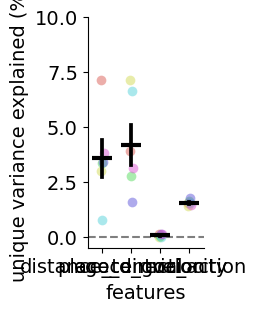

In [81]:
models = [f.split("_", 1)[-1] for f in reduced_models]
reload(ve)
f, ax = plt.subplots(figsize=(1.5, 3))
ve.plot_variance_explained(
    cpd_df, features=models, plot_single_subject=True, print_stats=True, orientation="vertical", ax=ax
)
ax.set_ylim(-0.5, 10)

# extra features, interactions 

In [63]:
results_df = lms.load_model_set_cv_scores(
    "feature_interactions_full", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)

                                             model_1  \
0  place-direction-velocity-distance_to_goal-egoc...   
1  place-direction-velocity-distance_to_goal-egoc...   
2  place.direction.velocity.distance_to_goal.egoc...   
3  place.direction.velocity.distance_to_goal.egoc...   

                                             model_2    t_stat     p_val  \
0  place.direction-velocity-distance_to_goal-egoc...  4.261950  0.004000   
1  place.direction.velocity-distance_to_goal-egoc...  4.790610  0.002462   
2  place.direction-velocity-distance_to_goal-egoc... -1.980775  0.947763   
3  place.direction.velocity-distance_to_goal-egoc...  3.765537  0.006541   

   p_val_corr  
0    0.008000  
1    0.008000  
2    0.947763  
3    0.008722  


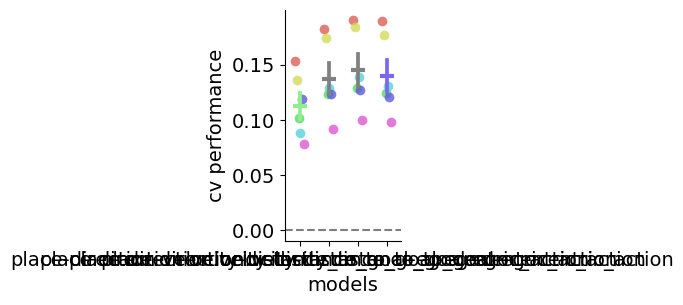

In [66]:
reload(mc)
mc.plot_full_feature_interactions(
    results_df,
    plot_single_subjects=True,
    print_stats=True,
    ax=None,
)

# population tuning summaries revisted

In [ ]:
from GridMaze.analysis.neGLM import tuning_summaries as ts
from GridMaze.maze import representations as mr

In [9]:
# distance tuning
distance_tuning_df = ts.get_population_unique_distance_to_goal_tuning_df()

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


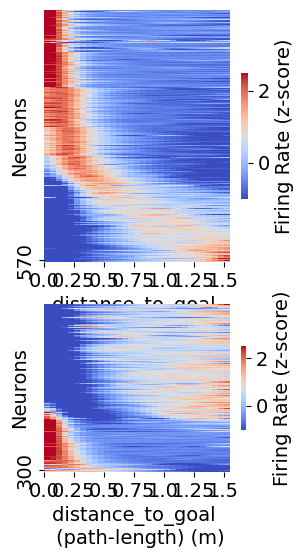

In [10]:
# plot
f, axes = plt.subplots(2, 1, figsize=(3, 6), height_ratios=[1.5, 1])
ts.plot_unique_distance_to_goal_tuning_heatmap(distance_tuning_df, axes=axes)
f.savefig("../results/nbeGLM/figures/unique_distance_tuning_heatmap.pdf")

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.placeDirectionTuningMetrics.parquet not found for m8.2022-07-26.maze


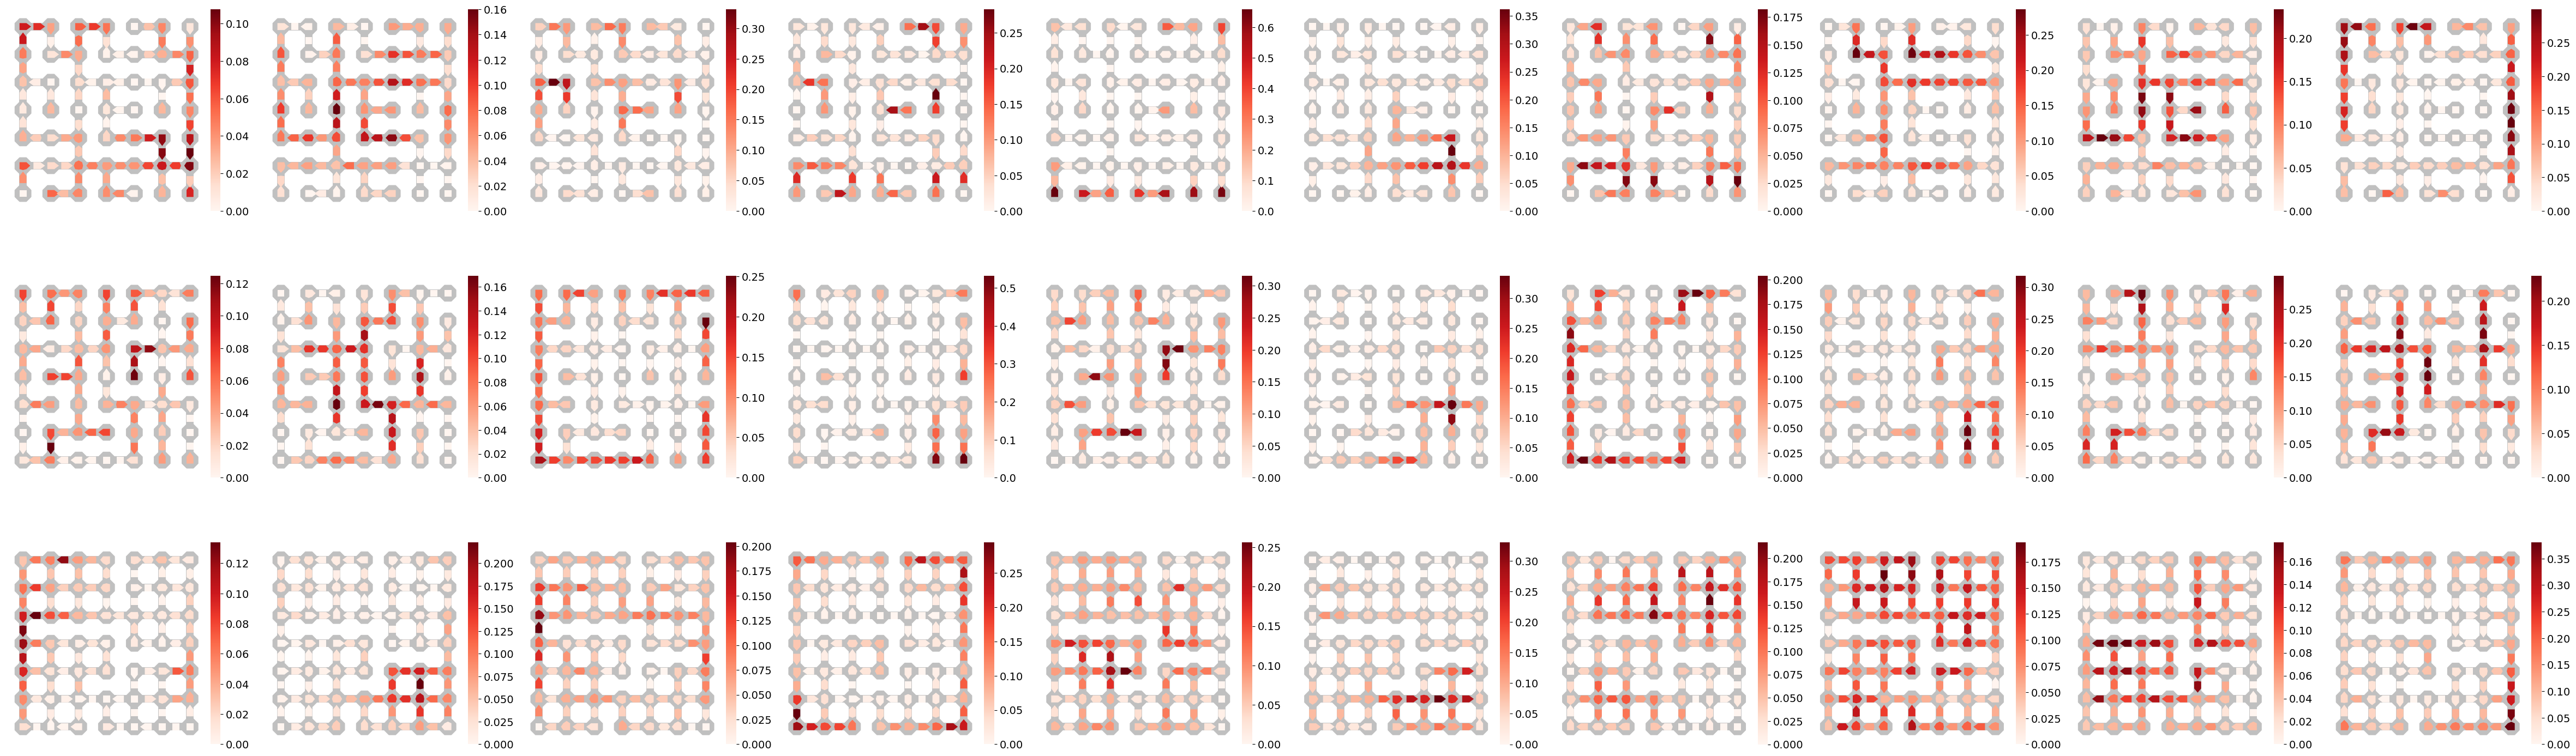

In [11]:
# place-direction tuning
dim_red = "nmf"
n_components = 10
f, axes = plt.subplots(3, n_components, figsize=(6 * n_components, 18))
for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    simple_maze = mr.get_simple_maze(maze_name)
    place_direction_tuning_df = ts.get_population_unique_place_direction_tuning_df(maze_name=maze_name)
    ts.plot_unique_place_direction_components(
        place_direction_tuning_df, simple_maze, dim_red=dim_red, n_components=n_components, axes=axes[i, :]
    )
f.savefig(f"../results/nbeGLM/figures/unique_place_direction_{dim_red}_components.pdf")